In [1]:

%load_ext autoreload
%autoreload 2

import pandas as pd
import os
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score, roc_auc_score, average_precision_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed


from utils import DEG
# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

GEADIENT_GENES_PATH = "/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined_corr>0.1.csv"

GENESETS = ["001", "002", "003", "004"]
DEPLETION_PERCENTS = ["0.00", "0.10", "0.20", "0.30", "0.40", "0.50", "0.60", "0.70", "0.80"] #"0.01", "0.05"
METHOD_NAME = ["baseline_nebula", "baseline_deseq2", "baseline_edgeR", "gradient_score_nebula", "PCA_nebula", "cNMF_nebula", "SVA_deseq2", "SVA_edgeR"]
PVAL_THR=[0.001, 0.005, 0.01, 0.05, 0.1, 0.15, 0.2]
ONLY_GENE_INTERSECTION= True
CORRECT_P_PSEUDOBULK = True

#columns names
CONTRAST_VARIABLE = "case_control"
CONTRAST_BASELINE = "control"
CONTRAST_STIM = "case"
P_VAL_COL_NAME = f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
LOGFC_COL_NAME = f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
GENE_COL_NAME = "gene"

# mitluple etst correction pvalue thr
LOGFC_THR=0
CORREVTION_METHOD = "fdr_bh"

# Read df

In [2]:
# df with dorsal graidnet genes
df_grad = pd.read_csv(GEADIENT_GENES_PATH)
df_grad


,Unnamed: 0,gene,mean_spearman,combined_p
0,31237,TESPA1,-0.470455,9.992007e-16
1,33964,ZNF385B,-0.447352,9.992007e-16
2,9413,AL138701.2,-0.438598,9.992007e-16
3,9554,AL139379.1,-0.425626,9.992007e-16
4,26830,PLEKHA7,-0.415725,9.992007e-16
...,...,...,...,...
1236,13895,CADM1,0.330092,9.992007e-16
1237,19063,HCN1,0.337687,9.992007e-16
1238,18289,GDA,0.375323,9.992007e-16
1239,27342,PRKG1,0.379187,9.992007e-16


In [3]:
# all_grad_df = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined.csv")
# all_grad_df = all_grad_df[all_grad_df.combined_p <= 0.05]
# all_grad_df

# Parallel read of all dfs

### Define how to process a single df

In [4]:
# def find_z_from_t(p_vals_t, logFC):
#     from scipy.stats import norm

#     # 2. Clip to avoid numerical issues at extremes
#     #    1e-300: minimum representable p-value
#     #    1-1e-15: avoid log(0) when p=1 exactly
#     p_vals_t = np.clip(p_vals_t, 1e-300, 1 - 1e-15)

#     # 3. Convert two-sided p-value to |z|
#     #    norm.ppf() is the inverse CDF: Φ^(-1)
#     #    norm.ppf(1 - p/2) gives the positive z-score
#     abs_z = -norm.ppf(p_vals_t / 2)  # or: norm.ppf(1 - p_vals/2)

#     # 4. Add sign from logFC direction
#     z_scores = abs_z * np.sign(logFC)

#     # 5. Handle any remaining NaN (from p=0 or p=1 edge cases)
#     z_scores = np.where(np.isfinite(z_scores), z_scores, 0.0)

#     return z_scores

def process_one(
    geneset,
    dataset,
    depletion,
    method,
    p_val_thr,
    DATASET_FOLDER,
    df_true_degs,
    interestion_genes,
    ONLY_GENE_INTERSECTION,
    JUST_RETURN_GENES
):
    results_folder = os.path.join(DATASET_FOLDER, dataset, method)
    csv_result_path = os.path.join(
        results_folder, f"{dataset}-{method}_results.csv"
    )

    if not os.path.exists(csv_result_path):
        return None

    df_results = pd.read_csv(csv_result_path)

    if JUST_RETURN_GENES:
        return df_results[GENE_COL_NAME]
    
    # Determine which stat column
    if "deseq2" in method:
        stat_col = "stat" 
    else:
        stat_col = None

    # Define col to keep
    cols_to_keep = [GENE_COL_NAME, LOGFC_COL_NAME, P_VAL_COL_NAME]

    if stat_col and stat_col in df_results.columns:
        cols_to_keep.append(stat_col)

    df_results = df_results[cols_to_keep]
    df_results["depletion"] = depletion
    df_results["method"] = method

    if CORRECT_P_PSEUDOBULK:
        if "deseq2" in method:
            # DESeq2 stat column is already a z-score
            z_scores = df_results[stat_col].tolist()
            d = DEG.fdrtool_empirical_null(z_scores)
            df_results[P_VAL_COL_NAME] = d["pval"]
        
        # elif "edgeR" in method:
        #     # Convert F-statistic to z-score: z 
        #     z_scores = find_z_from_t(df_results[P_VAL_COL_NAME], df_results[LOGFC_COL_NAME]).tolist()    

        #     d = DEG.fdrtool_empirical_null(z_scores)
        #     df_results[P_VAL_COL_NAME] = d["pval"]
    
    # Contnius wht mutliple test crrection
    ADJ_P_VAL_COL_NAME = f"adj_{P_VAL_COL_NAME}"
    df_results[ADJ_P_VAL_COL_NAME] = multipletests(
        df_results[P_VAL_COL_NAME], method=CORREVTION_METHOD
    )[1]

    # ATTENTION: filter after adjusting, otherwise you coudl have leakacge of info
    if ONLY_GENE_INTERSECTION:
        df_results = df_results[df_results[GENE_COL_NAME].isin(interestion_genes)]

    df_results["is_significant"] = (
        (df_results[ADJ_P_VAL_COL_NAME] <= p_val_thr)
        & (np.abs(df_results[LOGFC_COL_NAME]) >= LOGFC_THR)
    )

    df_results["is_true_DEG"] = df_results[GENE_COL_NAME].isin(
        df_true_degs["gene_id"].values
    )
    df_results["is_gradient"] = df_results[GENE_COL_NAME].isin(
        df_grad["gene"].values
    )

    precision = precision_score(df_results["is_true_DEG"], df_results["is_significant"])
    recall = recall_score(df_results["is_true_DEG"], df_results["is_significant"])
    f1 = f1_score(df_results["is_true_DEG"], df_results["is_significant"])
    balanced_accuracy = balanced_accuracy_score(
        df_results["is_true_DEG"], df_results["is_significant"]
    )

    TP = ((df_results["is_true_DEG"]) & (df_results["is_significant"])).sum()
    FP = ((~df_results["is_true_DEG"]) & (df_results["is_significant"])).sum()
    TN = ((~df_results["is_true_DEG"]) & (~df_results["is_significant"])).sum()
    FN = ((df_results["is_true_DEG"]) & (~df_results["is_significant"])).sum()

    pct_significant_and_gradient = (
        ((df_results["is_significant"]) & (df_results["is_gradient"])).sum()
        / (df_results["is_significant"].sum() + 1e-10)
    )

    df_results["score"] = -np.log10(df_results[ADJ_P_VAL_COL_NAME] + 1e-300)
    auc_roc = roc_auc_score(df_results["is_true_DEG"], df_results["score"])
    auc_prc = average_precision_score(df_results["is_true_DEG"], df_results["score"])

    return {
        "geneset": geneset,
        "dataset": dataset,
        "depletion": depletion,
        "method": method,
        "p_val_thr": str(p_val_thr),
        "TP": TP,
        "FP": FP,
        "TN": TN,
        "FN": FN,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Balanced Accuracy": balanced_accuracy,
        "AUC_ROC": auc_roc,
        "AUC_PRC": auc_prc,
        "Percentage Significant Gradient Genes": pct_significant_and_gradient,
    }


### Find gene intersection: Create all Jobs + Run

In [5]:
jobs_just_for_genes = []

for geneset in GENESETS:
    DATASET_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{geneset}/depleted_versions"
    datasets = sorted(os.listdir(DATASET_FOLDER))

    for dataset in datasets:
        depletion = dataset.split("_")[1]
        if depletion not in DEPLETION_PERCENTS:
            continue

        for method in METHOD_NAME:
            jobs_just_for_genes.append(
                delayed(process_one)(
                    geneset=geneset,
                    dataset=dataset,
                    depletion=depletion,
                    method=method,
                    p_val_thr=None,
                    DATASET_FOLDER=DATASET_FOLDER,
                    df_true_degs=None,
                    interestion_genes=None,
                    ONLY_GENE_INTERSECTION=False,
                    JUST_RETURN_GENES=True, # ATTENTION HERE
                )
            )

results = Parallel(
    n_jobs=-1,
    backend="loky",
    verbose=10
)(
    jobs_just_for_genes
)

interestion_genes = set.intersection(*(set(r) for r in results if r is not None))
len(interestion_genes)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.


[Parallel(n_jobs=-1)]: Done   2 out of 288 | elapsed:   11.3s
[Parallel(n_jobs=-1)]: Done  17 out of 288 | elapsed:   11.7s
[Parallel(n_jobs=-1)]: Done  32 out of 288 | elapsed:   11.9s
[Parallel(n_jobs=-1)]: Done  49 out of 288 | elapsed:   12.3s
[Parallel(n_jobs=-1)]: Done  66 out of 288 | elapsed:   12.5s
[Parallel(n_jobs=-1)]: Done  85 out of 288 | elapsed:   12.8s
[Parallel(n_jobs=-1)]: Done 104 out of 288 | elapsed:   13.0s
[Parallel(n_jobs=-1)]: Done 125 out of 288 | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Done 146 out of 288 | elapsed:   13.5s
[Parallel(n_jobs=-1)]: Done 169 out of 288 | elapsed:   13.8s
[Parallel(n_jobs=-1)]: Done 192 out of 288 | elapsed:   14.1s
[Parallel(n_jobs=-1)]: Done 222 out of 288 | elapsed:   14.5s remaining:    4.3s
[Parallel(n_jobs=-1)]: Done 251 out of 288 | elapsed:   14.7s remaining:    2.2s
[Parallel(n_jobs=-1)]: Done 280 out of 288 | elapsed:   15.1s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done 288 out of 288 | elapsed:   15.2s finished


16939

### Create d results: Create all Jobs + Run

In [6]:
jobs = []

for geneset in GENESETS:
    DATASET_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{geneset}/depleted_versions"
    TRUE_DEG_PATH = f"{DATASET_FOLDER}/../initial_perturbed/genes.csv"
    df_true_degs = pd.read_csv(TRUE_DEG_PATH) # PSEICIFC FOR THIS GENESET
    datasets = sorted(os.listdir(DATASET_FOLDER))

    for dataset in datasets:
        depletion = dataset.split("_")[1]
        if depletion not in DEPLETION_PERCENTS:
            continue

        for p_val_thr in PVAL_THR:

            for method in METHOD_NAME:
                jobs.append(
                    delayed(process_one)(
                        geneset=geneset,
                        dataset=dataset,
                        depletion=depletion,
                        method=method,
                        p_val_thr=p_val_thr,
                        DATASET_FOLDER=DATASET_FOLDER,
                        df_true_degs=df_true_degs,
                        interestion_genes=interestion_genes,
                        ONLY_GENE_INTERSECTION=True, #ATTENTION
                        JUST_RETURN_GENES=False, # ATTENTION HERE
                    )
                )

results = Parallel(
    n_jobs=-1,
    backend="loky",
    verbose=10
)(
    jobs
)

#Merge
rows = [r for r in results if r is not None]
df_summary = pd.DataFrame(rows)
df_summary

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.12441420555114746s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done    2 out of 2016 | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done   17 out of 2016 | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   32 out of 2016 | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done   49 out of 2016 | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done   66 out of 2016 | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done   85 out of 2016 | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  112 out of 2016 | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  154 out of 2016 | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  196 out of 2016 | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Batch computation too slow (2.0072745340427884s.) Setting batch_size=1.
[Parallel(n_jobs=-1)]: Done  242 out of 2016 | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done  288 out of 2016 | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 

,geneset,dataset,depletion,method,p_val_thr,TP,FP,TN,FN,Precision,Recall,F1,Balanced Accuracy,AUC_ROC,AUC_PRC,Percentage Significant Gradient Genes
0,001,depleted_0.00_dorsal_matrix,0.00,baseline_nebula,0.001,48,1,16681,209,0.979592,0.186770,0.313725,0.593355,0.814308,0.423548,0.102041
1,001,depleted_0.00_dorsal_matrix,0.00,baseline_deseq2,0.001,61,9,16673,196,0.871429,0.237354,0.373089,0.618407,0.798641,0.352766,0.071429
2,001,depleted_0.00_dorsal_matrix,0.00,baseline_edgeR,0.001,15,0,16682,242,1.000000,0.058366,0.110294,0.529183,0.637124,0.272920,0.066667
3,001,depleted_0.00_dorsal_matrix,0.00,gradient_score_nebula,0.001,49,1,16681,208,0.980000,0.190661,0.319218,0.595301,0.822978,0.428033,0.100000
4,001,depleted_0.00_dorsal_matrix,0.00,PCA_nebula,0.001,49,3,16679,208,0.942308,0.190661,0.317152,0.595241,0.818614,0.405249,0.076923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1983,004,depleted_0.80_dorsal_matrix,0.80,gradient_score_nebula,0.2,97,120,16534,188,0.447005,0.340351,0.386454,0.666573,0.789784,0.353423,0.078341
1984,004,depleted_0.80_dorsal_matrix,0.80,PCA_nebula,0.2,103,159,16495,182,0.393130,0.361404,0.376600,0.675928,0.797163,0.363782,0.068702
1985,004,depleted_0.80_dorsal_matrix,0.80,cNMF_nebula,0.2,108,163,16491,177,0.398524,0.378947,0.388489,0.684580,0.796411,0.370888,0.073801
1986,004,depleted_0.80_dorsal_matrix,0.80,SVA_deseq2,0.2,32,108,16546,253,0.228571,0.112281,0.150588,0.552898,0.615671,0.081674,0.285714


In [7]:
df_summary[df_summary.method =="cNMF_nebula"].reset_index()

,index,geneset,dataset,depletion,method,p_val_thr,TP,FP,TN,FN,Precision,Recall,F1,Balanced Accuracy,AUC_ROC,AUC_PRC,Percentage Significant Gradient Genes
0,5,001,depleted_0.00_dorsal_matrix,0.00,cNMF_nebula,0.001,40,3,16679,217,0.930233,0.155642,0.266667,0.577731,0.817954,0.384716,0.093023
1,13,001,depleted_0.00_dorsal_matrix,0.00,cNMF_nebula,0.005,53,7,16675,204,0.883333,0.206226,0.334385,0.602903,0.817954,0.384716,0.066667
2,21,001,depleted_0.00_dorsal_matrix,0.00,cNMF_nebula,0.01,59,12,16670,198,0.830986,0.229572,0.359756,0.614426,0.817954,0.384716,0.070423
3,29,001,depleted_0.00_dorsal_matrix,0.00,cNMF_nebula,0.05,76,38,16644,181,0.666667,0.295720,0.409704,0.646721,0.817954,0.384716,0.070175
4,37,001,depleted_0.00_dorsal_matrix,0.00,cNMF_nebula,0.1,84,71,16611,173,0.541935,0.326848,0.407767,0.661296,0.817954,0.384716,0.077419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,1953,004,depleted_0.80_dorsal_matrix,0.80,cNMF_nebula,0.01,63,11,16643,222,0.851351,0.221053,0.350975,0.610196,0.796411,0.370888,0.081081
234,1961,004,depleted_0.80_dorsal_matrix,0.80,cNMF_nebula,0.05,79,40,16614,206,0.663866,0.277193,0.391089,0.637396,0.796411,0.370888,0.100840
235,1969,004,depleted_0.80_dorsal_matrix,0.80,cNMF_nebula,0.1,90,81,16573,195,0.526316,0.315789,0.394737,0.655463,0.796411,0.370888,0.070175
236,1977,004,depleted_0.80_dorsal_matrix,0.80,cNMF_nebula,0.15,100,122,16532,185,0.450450,0.350877,0.394477,0.671776,0.796411,0.370888,0.076577


# Plot Metrics

In [8]:
df_summary_single_p = df_summary[df_summary["p_val_thr"] == "0.05"].copy()

2026-02-18 14:37:37 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-18 14:37:37 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-02-18 14:37:38 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-18 14:37:38 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-18 14:37:40 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-18 14:37:40 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-18 14:37:41 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

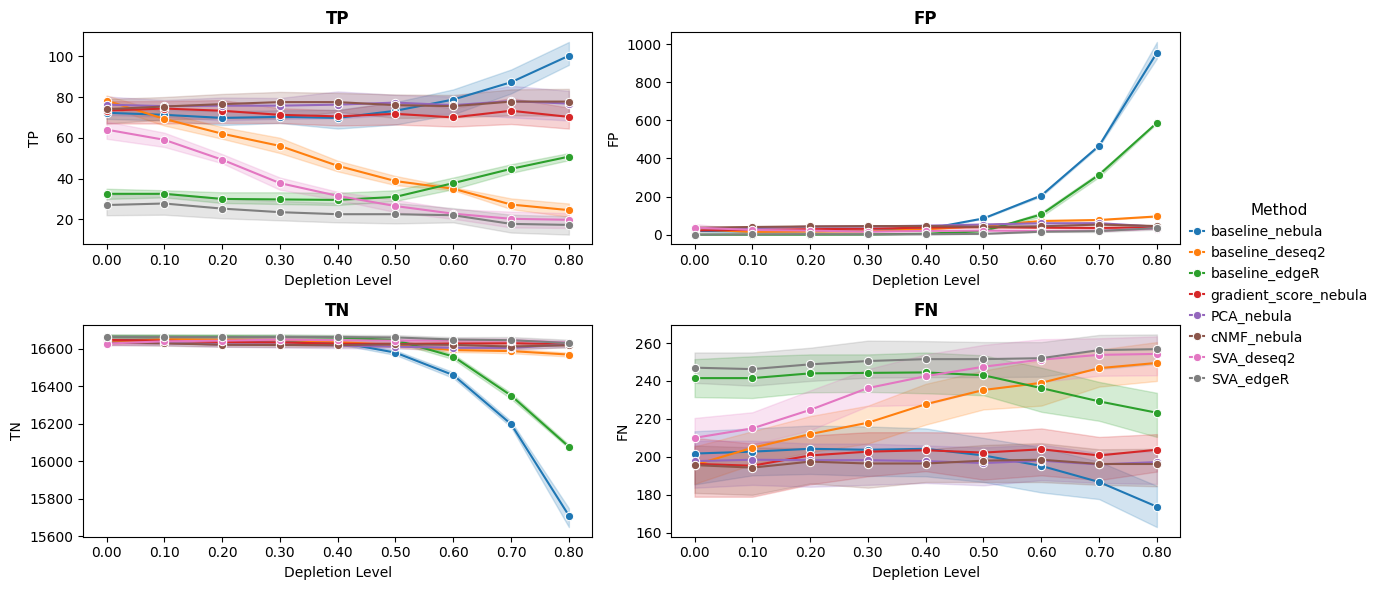

2026-02-18 14:37:43 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-18 14:37:43 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-18 14:37:44 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-18 14:37:44 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-18 14:37:46 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

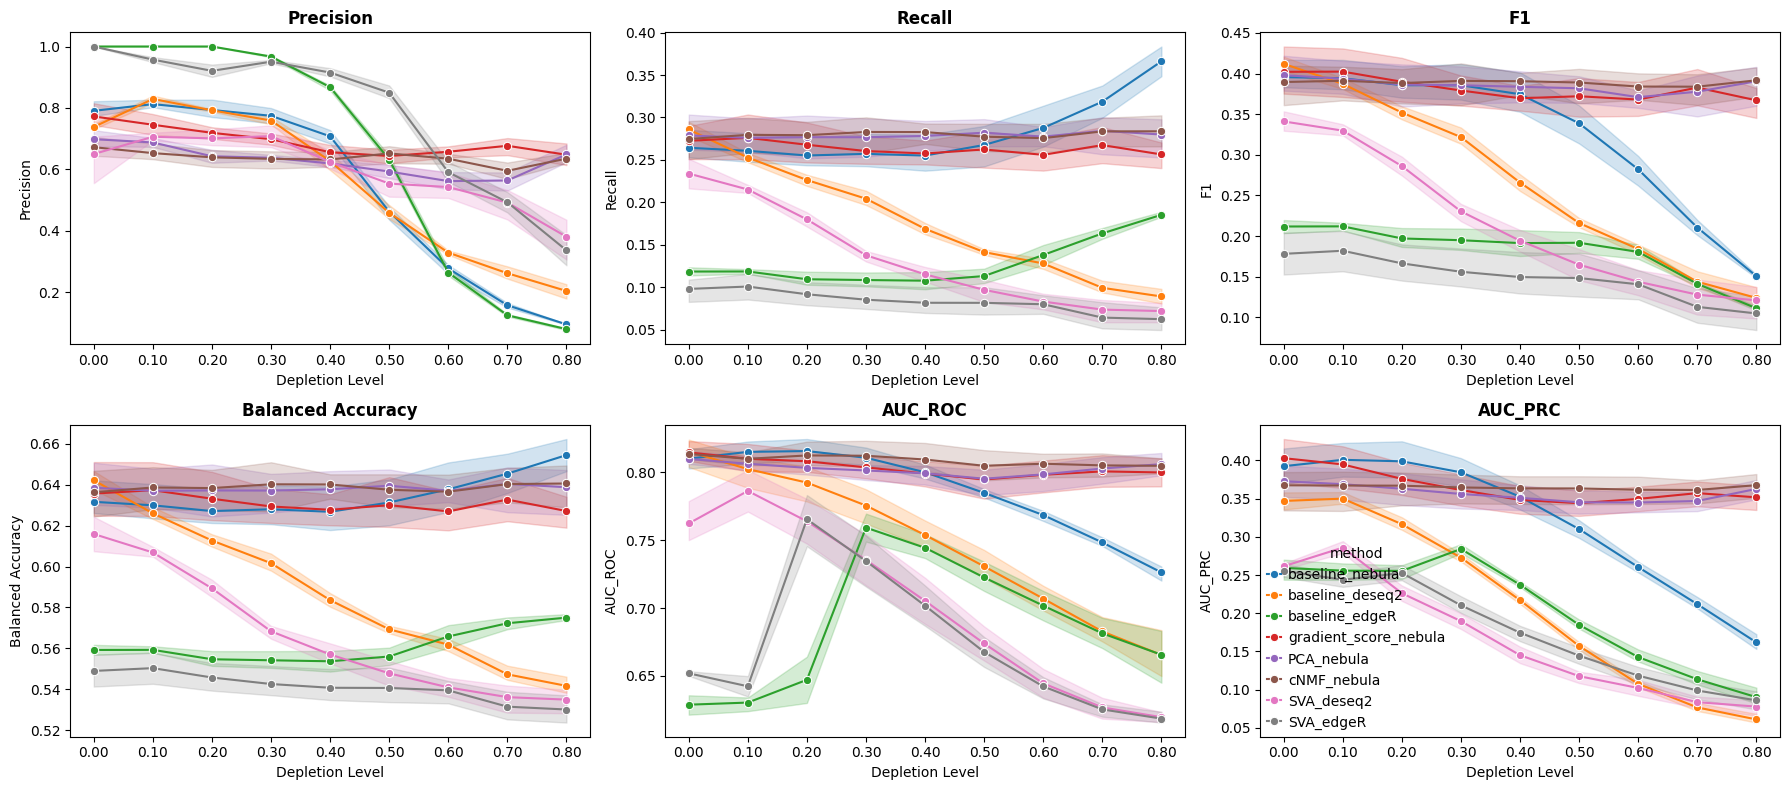

In [9]:
CONFUSION_METRICS = ["TP", "FP", "TN", "FN"]# "Percentage Significant Gradient Genes"]
PERFORMANCE_METRICS = ["Precision", "Recall", "F1", "Balanced Accuracy", "AUC_ROC", "AUC_PRC"]

ERROR_BAR = "ci" # sd, se, ci, pi

fig1, axes1 = plt.subplots(2, 2, figsize=(12, 6))
axes1 = axes1.flatten()

for i, metric in enumerate(CONFUSION_METRICS):
    sns.lineplot(data=df_summary_single_p, x="depletion", y=metric, hue="method", 
                 ax=axes1[i], marker='o', errorbar=ERROR_BAR)
    axes1[i].set_title(metric, fontsize=12, fontweight='bold')
    axes1[i].set_xlabel("Depletion Level", fontsize=10)
    axes1[i].set_ylabel(metric, fontsize=10)
    axes1[i].get_legend().remove()  # Remove all individual legends

# Grab handles/labels from the last axis and place legend outside
handles, labels = axes1[-1].get_legend_handles_labels()
fig1.legend(handles, labels, 
            loc='center right',           # anchor point on the legend box
            bbox_to_anchor=(1.15, 0.5),   # (x, y) in figure fraction — push right
            title="Method", fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()

# Second figure: Performance metrics (2 rows × 3 columns)
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 8))
axes2 = axes2.flatten()

for i, metric in enumerate(PERFORMANCE_METRICS):
    sns.lineplot(data=df_summary_single_p, x="depletion", y=metric, hue="method", 
                 ax=axes2[i], marker='o', errorbar=ERROR_BAR)  # Added errorbar
    axes2[i].set_title(metric, fontsize=12, fontweight='bold')
    axes2[i].set_xlabel("Depletion Level", fontsize=10)
    axes2[i].set_ylabel(metric, fontsize=10)
    #axes2[i].set_ylim(0, 1.1)
    
    if i < len(PERFORMANCE_METRICS) - 1:
        axes2[i].get_legend().remove()

plt.tight_layout()
plt.show()

# Metrics on p-valaue

2026-02-18 14:37:53 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-18 14:37:53 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-18 14:37:54 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-18 14:37:54 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-02-18 14:37:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-18 14:37:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-18 14:37:56 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-18 14:37:56 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-18 14:37:57 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

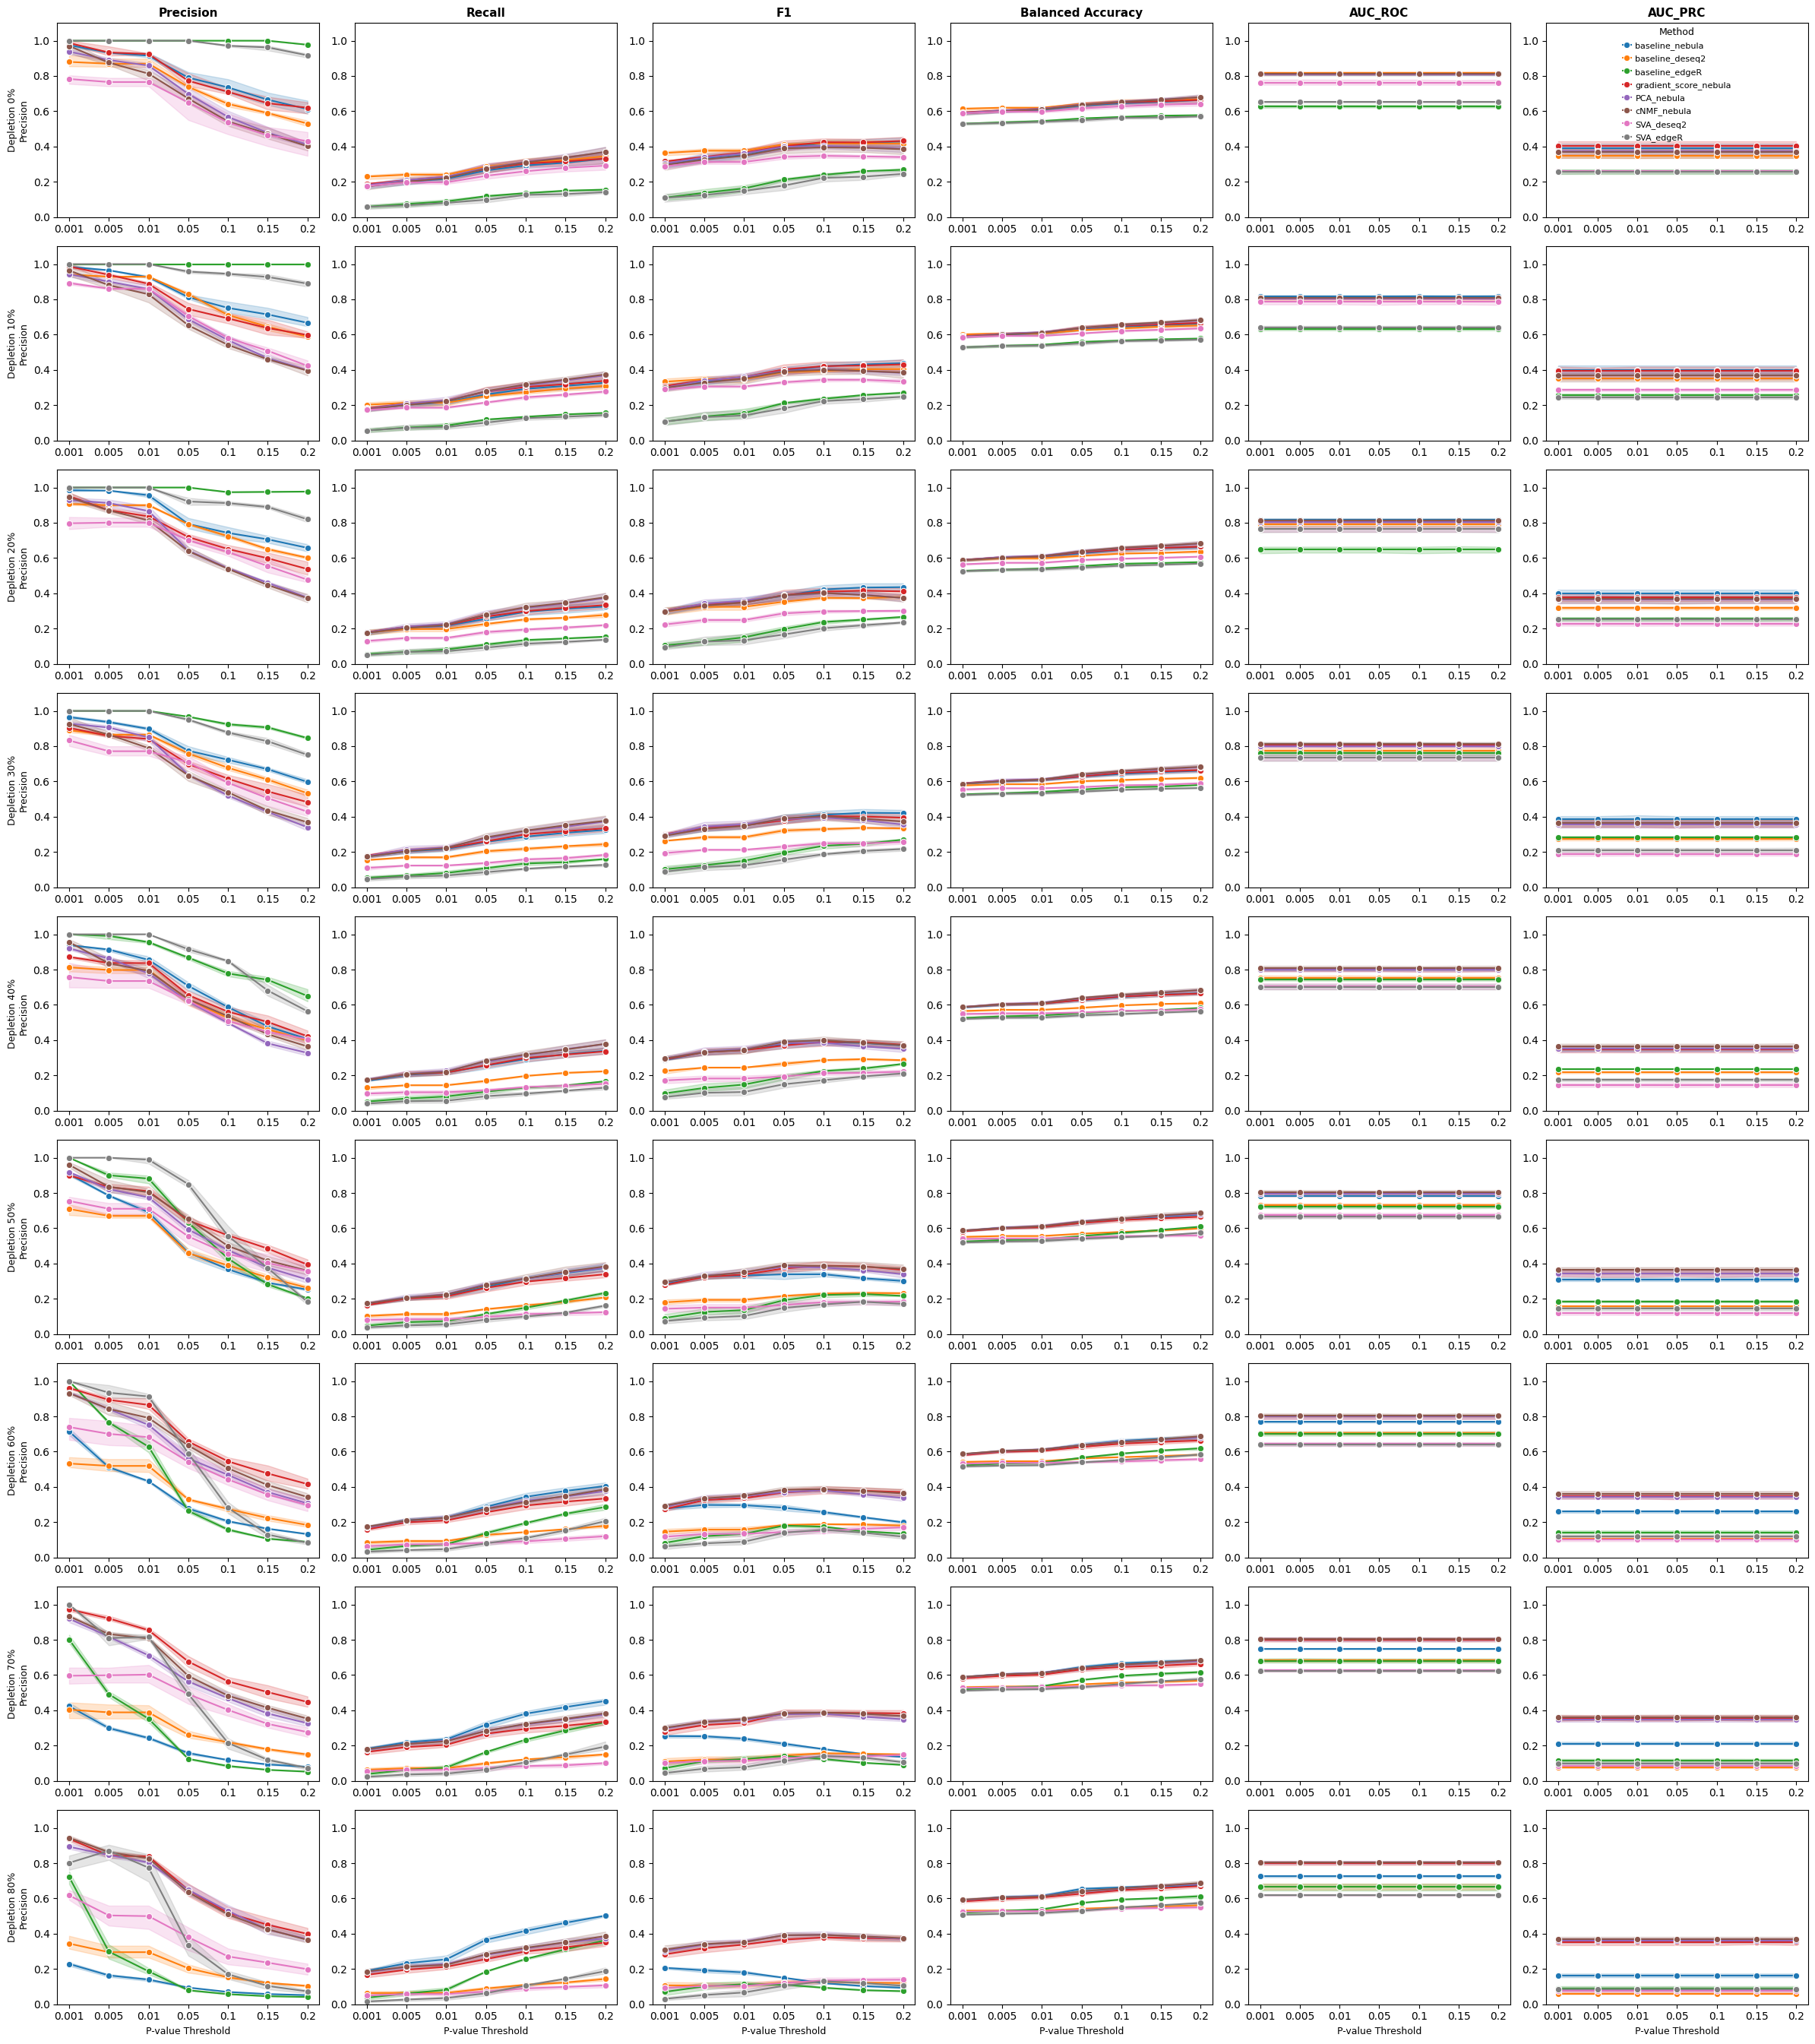

In [10]:
import matplotlib.ticker as ticker


# Get unique depletion levels and metrics
depletion_levels = sorted(df_summary['depletion'].unique())
n_depletions = len(depletion_levels)
n_metrics = len(PERFORMANCE_METRICS)
p_val_thresholds = sorted(df_summary['p_val_thr'].unique())

# Create the grid: rows = depletions, cols = metrics
fig, axes = plt.subplots(n_depletions, n_metrics, figsize=(4*n_metrics, 3*n_depletions))

# Handle case where there's only one row or column
if n_depletions == 1:
    axes = axes.reshape(1, -1)
if n_metrics == 1:
    axes = axes.reshape(-1, 1)

# Loop through each depletion level (rows)
for row_idx, depletion in enumerate(depletion_levels):

    # Filter data for this depletion level
    depletion_data = df_summary[df_summary['depletion'] == depletion]
    
    # Loop through each metric (columns)
    for col_idx, metric in enumerate(PERFORMANCE_METRICS):
        ax = axes[row_idx, col_idx]
        ax.set_ylim(0, 1.1)
        
        # Create lineplot with errorbars
        sns.lineplot(data=depletion_data, x='p_val_thr', y=metric, hue='method',
                     marker='o', errorbar=ERROR_BAR, ax=ax)
        
        # Set x-axis ticks to exactly match your p-value thresholds
        #ax.set_xticks(p_val_thresholds)
        
        # Add title only to top row
        if row_idx == 0:
            ax.set_title(metric, fontsize=11, fontweight='bold')
        
        # Add y-label only to first column - convert depletion to float first
        if col_idx == 0:
            ax.set_ylabel(f'Depletion {float(depletion):.0%}\n{metric}', fontsize=9)
        else:
            ax.set_ylabel('')
        
        # Add x-label only to bottom row
        if row_idx == n_depletions - 1:
            ax.set_xlabel('P-value Threshold', fontsize=9)
        else:
            ax.set_xlabel('')
        
        # Remove legend from all but top-right plot
        if not (row_idx == 0 and col_idx == n_metrics - 1):
            ax.get_legend().remove()
        else:
            ax.legend(title='Method', fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()

# Deseq2 p-value Investigation

In [11]:
geneset = "001"
dataset = "depleted_0.00_dorsal_matrix"
CORREVTION_METHOD="fdr_bh"


### p-value distribution (calibration)

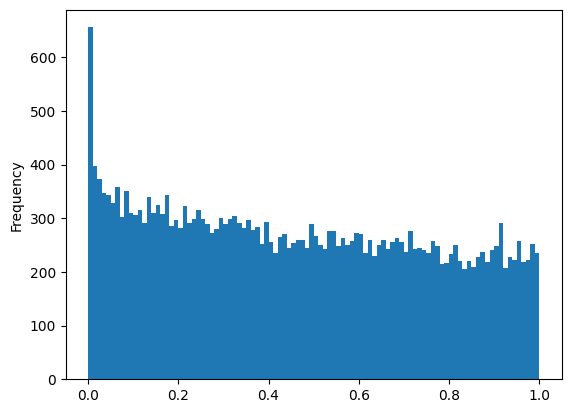

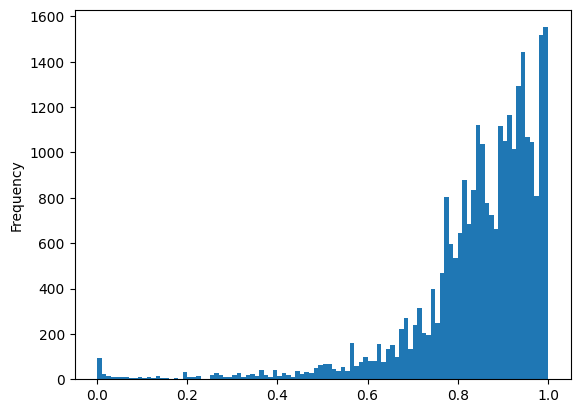

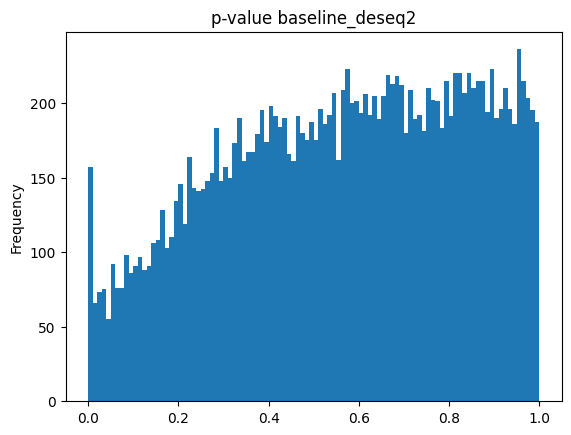

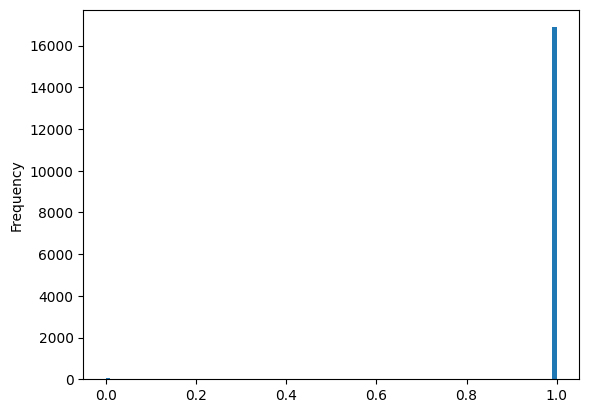

'\nINTERPRETATION:\n- p-value NOT-calibrated\n- indeed starnge after correction \n'

In [12]:
method = "baseline_nebula"
df_nebula = pd.read_csv(f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{geneset}/depleted_versions/{dataset}/{method}/{dataset}-{method}_results.csv")
df_nebula["adj_p_case_controlcase"] = multipletests(df_nebula["p_case_controlcase"],method=CORREVTION_METHOD)[1]

df_nebula["p_case_controlcase"].plot(kind="hist", bins=100); plt.show()
df_nebula["adj_p_case_controlcase"].plot(kind="hist", bins=100); plt.show()

"""
INTERPRETATION:
- p-value calibrated
"""

method = "baseline_deseq2" #"baseline_deseq2"
df_deseq2 = pd.read_csv(f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{geneset}/depleted_versions/{dataset}/{method}/{dataset}-{method}_results.csv")
df_deseq2["adj_p_case_controlcase"] = multipletests(df_deseq2["p_case_controlcase"],method=CORREVTION_METHOD)[1]

df_deseq2["p_case_controlcase"].plot(kind="hist", bins=100); plt.title(f"p-value {method}"); plt.show()
df_deseq2["adj_p_case_controlcase"].plot(kind="hist", bins=100); plt.show()

"""
INTERPRETATION:
- p-value NOT-calibrated
- indeed starnge after correction 
"""


### Fix Deseq2 p-value distribtion with "Emprirical Null Estimator"

dict_keys(['pval', 'qval', 'lfdr', 'sigma', 'eta0'])
0.7968


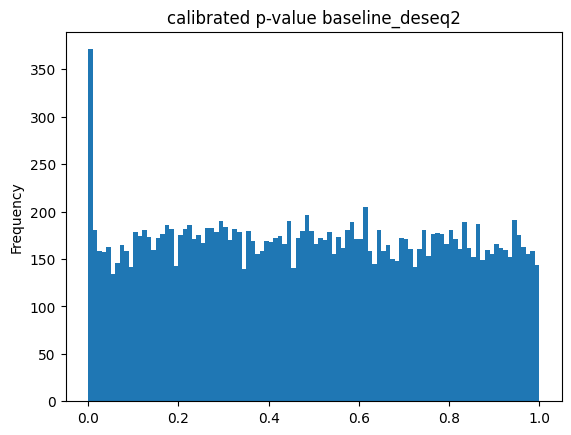

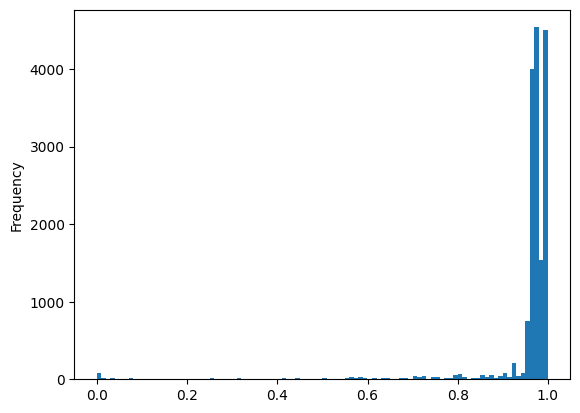

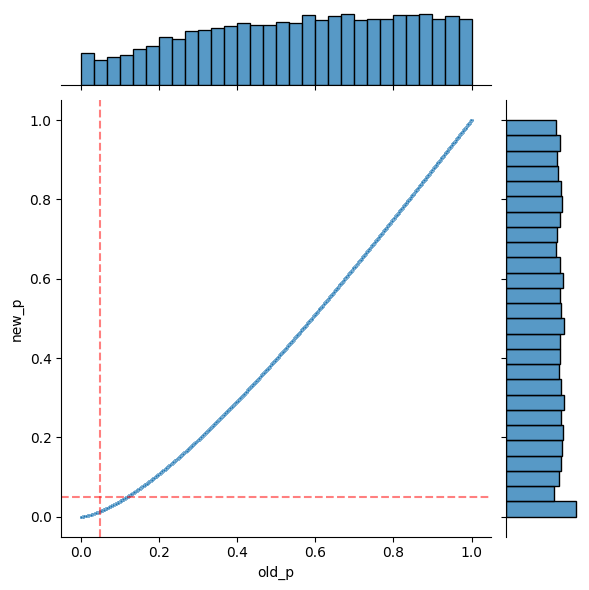

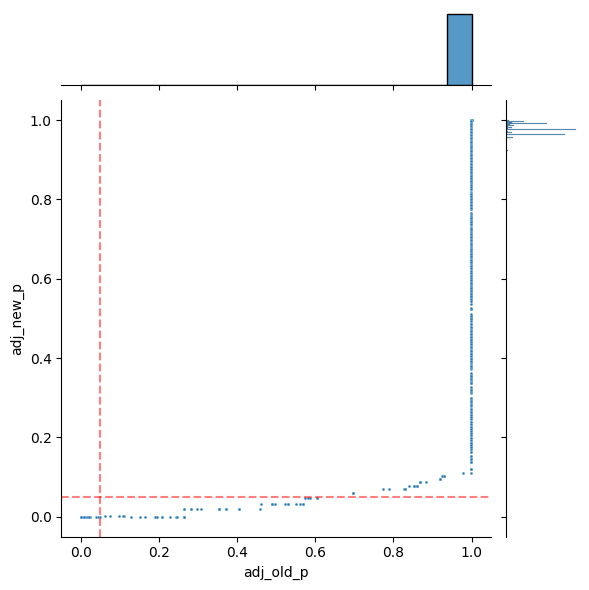

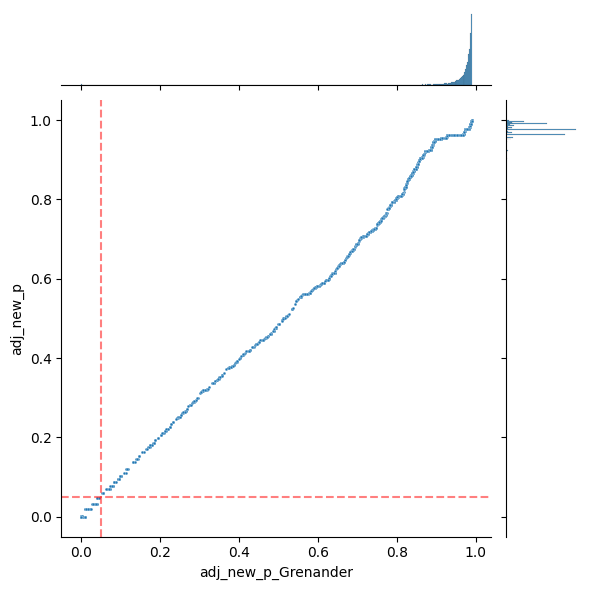

'\nINTERPRETATION:\n- new p-value calibrated (unform)\n- new_crretiuon and granadier correation, are the same: straight line (in particlar in low p.values)\n'

In [13]:
# Calculate wiht old pvalue N(0,1)
df_deseq2["old_p"] = df_deseq2["p_case_controlcase"]
df_deseq2["adj_old_p"] = multipletests(df_deseq2["old_p"],method=CORREVTION_METHOD)[1]

# Calculate new pvlaue N(o, sigma?2)
d = DEG.fdrtool_empirical_null(df_deseq2["stat"])
print(d.keys())
print(d["sigma"])

df_deseq2["new_p"] = d["pval"]
df_deseq2["adj_new_p"] = multipletests(df_deseq2["new_p"],method=CORREVTION_METHOD)[1]

# Add another way (less stringet) for correction pvlaue
df_deseq2["adj_new_p_Grenander"] = d["qval"]

def plot_joint_distribution(df, col_x, col_y, thr=0.05, min=None, max=None, log_scale=False):

    g = sns.jointplot(data=df, x=col_x, y=col_y, kind="scatter", s=4,)
    g.ax_joint.axvline(thr, linestyle="--", color="red", alpha=0.5)
    g.ax_joint.axhline(thr, linestyle="--", color="red", alpha=0.5)
    if (min is not None) & (max is not None):
        g.ax_joint.set_ylim(min, max)
        g.ax_joint.set_xlim(min, max)
    if log_scale:
        g.ax_joint.set_xscale("log")
        g.ax_joint.set_yscale("log")
    plt.show()

df_deseq2["new_p"].plot(kind="hist", bins=100); plt.title(f"calibrated p-value {method}"); plt.show()
df_deseq2["adj_new_p"].plot(kind="hist", bins=100); plt.show()

plot_joint_distribution(df_deseq2, "old_p", "new_p")
plot_joint_distribution(df_deseq2, "adj_old_p", "adj_new_p")
plot_joint_distribution(df_deseq2, "adj_new_p_Grenander", "adj_new_p")


"""
INTERPRETATION:
- new p-value calibrated (unform)
- new_crretiuon and granadier correation, are the same: straight line (in particlar in low p.values)
"""

# p-value distribution Nebula Vs Deseq

This means:

A gene that varies consistently across donors → both methods agree
A gene that varies a lot between cells within donors → Nebula captures it, DESeq2 pseudobulk misses it or weights it differently
A gene where one donor drives the signal → DESeq2 may call it significant (small N = outlier-sensitive), Nebula may not (random effect absorbs it)

The practical consequence
The cloud scatter you see is expected when you have few donors but many cells per donor — the two models are genuinely measuring different sources of variance. Neither is wrong. They answer different questions:

DESeq2 pseudobulk: conservative, donor-level signal, robust when donors ≥ 6
Nebula: uses all cell-level information, more powerful with few donors, but depends heavily on the mixed model being correctly specified

In [ ]:
min=np.min([df_p["adj_p_case_controlcase"].min(), df_p["adj_new_p"].min()]).clip(1e-40)
min

NameError: name 'df_p' is not defined

2026-02-18 14:42:36 | [INFO] Embedded R ended.
2026-02-18 14:42:37 | [INFO] Embedded R ended.
2026-02-18 14:42:38 | [INFO] Embedded R ended.
2026-02-18 14:42:39 | [INFO] Embedded R ended.
2026-02-18 14:42:40 | [INFO] Embedded R ended.
2026-02-18 14:42:41 | [INFO] Embedded R ended.
2026-02-18 14:42:42 | [INFO] Embedded R ended.
2026-02-18 14:42:43 | [INFO] Embedded R ended.
2026-02-18 14:42:44 | [INFO] Embedded R ended.
2026-02-18 14:42:45 | [INFO] Embedded R ended.
2026-02-18 14:42:46 | [INFO] Embedded R ended.
2026-02-18 14:42:47 | [INFO] Embedded R ended.
2026-02-18 14:42:48 | [INFO] Embedded R ended.
2026-02-18 14:42:49 | [INFO] Embedded R ended.
2026-02-18 14:42:50 | [INFO] Embedded R ended.
2026-02-18 14:42:51 | [INFO] Embedded R ended.
2026-02-18 14:42:51 | [INFO] Embedded R ended.
2026-02-18 14:42:52 | [INFO] Embedded R ended.
2026-02-18 14:42:53 | [INFO] Embedded R ended.
2026-02-18 14:42:54 | [INFO] Embedded R ended.
2026-02-18 14:42:55 | [INFO] Embedded R ended.
2026-02-18 14

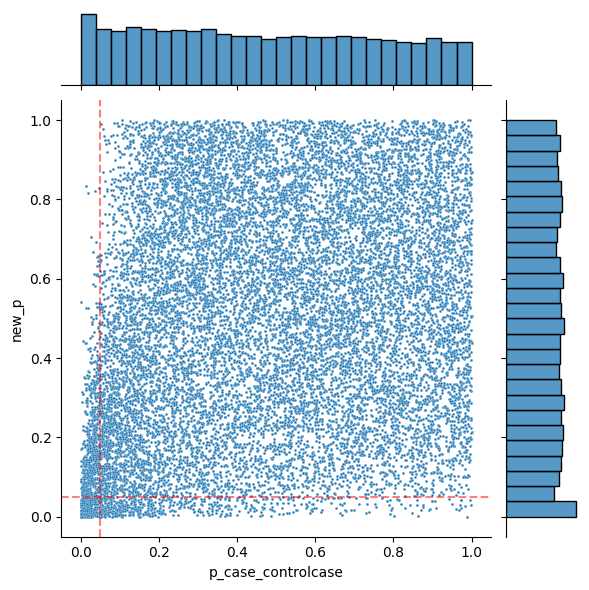

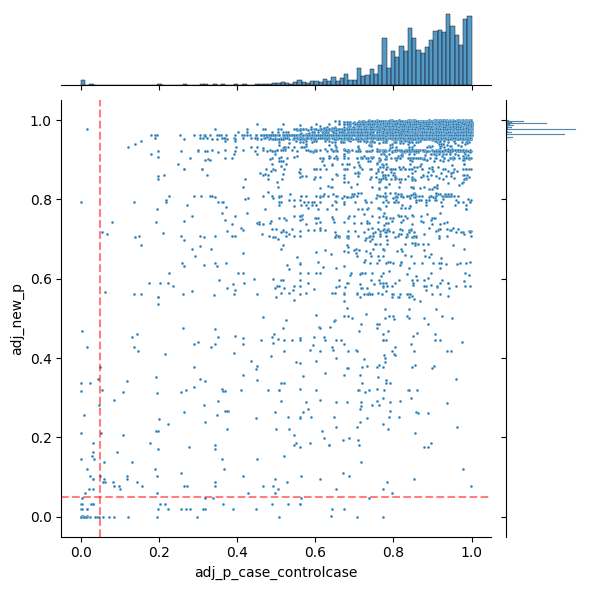

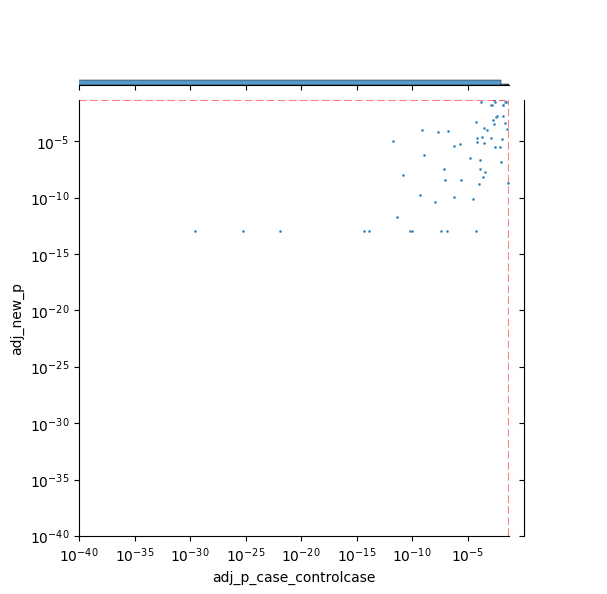

In [ ]:
# merge:
    # nebula: p-value as by test, corrected with CORREVTION_METHOD
    # deseq: pv-value reclauated with null estimator, corrected with CORREVTION_METHOD

# AFTER CORRECTION, FILTER TO HAVE SAME GENES (intersection)

df_p = df_nebula[
        ["gene", "adj_p_case_controlcase", "p_case_controlcase"]].merge(
        df_deseq2[
        ["gene", "new_p", "adj_new_p"]],
        how="inner", suffixes=("_nebula", "_deseq2"), on="gene")

df_p

plot_joint_distribution(df_p, "p_case_controlcase", "new_p")
plot_joint_distribution(df_p, "adj_p_case_controlcase", "adj_new_p")
min=np.min([df_p["adj_p_case_controlcase"].min(), df_p["adj_new_p"].min()]).clip(1e-40)
plot_joint_distribution(df_p, "adj_p_case_controlcase", "adj_new_p", min=min, max=0.05, log_scale=True)

# Corr spatial-gradient-genes with t-stat

In [ ]:
all_grad_df = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined.csv")
all_grad_df = all_grad_df[all_grad_df.combined_p <= 0.05]
all_grad_df


,gene,mean_spearman,combined_p
0,A1BG,-0.002360,5.349057e-07
1,A1BG-AS1,-0.007881,3.198023e-08
2,A1CF,0.007398,2.969691e-02
3,A2M,-0.002144,8.049117e-15
4,A2M-AS1,-0.000389,7.443913e-03
...,...,...,...
51517,MT-ND5,0.016423,3.799000e-02
51519,MT-CYB,0.030411,1.216229e-04
51524,ENSG00000278384,-0.031117,8.418097e-05
51525,ENSG00000273748,0.046480,4.222149e-09



######
 Processing 001 : depleted_0.00_dorsal_matrix : baseline_nebula 
######



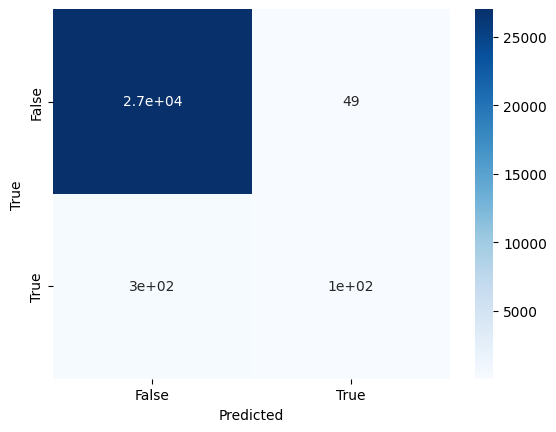

Precision: 0.680
Recall:    0.260
F1 Score:  0.376
Accuracy:  0.987
Clipping 19 genes with -log10(p) > 10


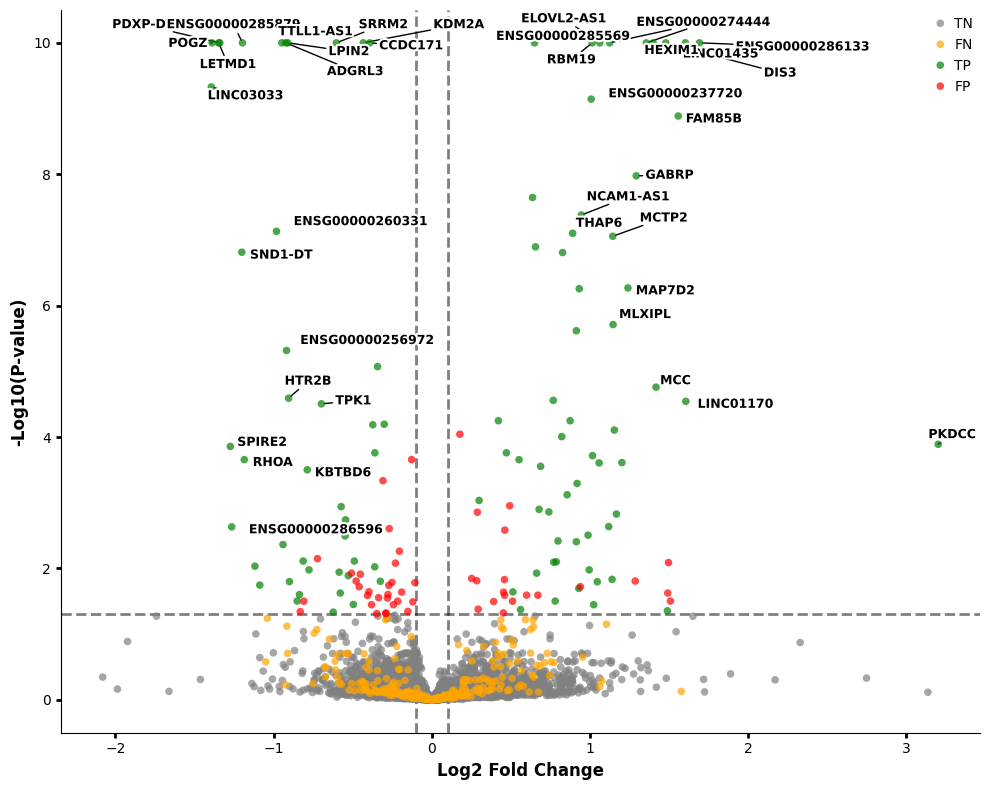

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,A1BG,-0.136511,0.001079,0.134554,False,False,0.871103,TN,-0.118915
1,A1BG-AS1,-0.039304,0.452345,0.884819,False,False,0.053146,TN,-0.002089
2,A1CF,-0.263262,0.013398,0.470287,False,False,0.327637,TN,-0.086254
3,A2M,0.235039,0.160924,0.777411,False,False,0.109350,TN,0.025701
4,A2M-AS1,0.019844,0.756238,0.952591,False,False,0.021093,TN,0.000419
...,...,...,...,...,...,...,...,...,...
27476,ZZEF1,-0.038951,0.101827,0.731021,False,False,0.136070,TN,-0.005300
27477,ZZZ3,0.023772,0.668428,0.936730,False,False,0.028385,TN,0.000675
27478,ENSG00000205653,0.391694,0.566351,0.913812,False,False,0.039143,TN,0.015332
27479,ENSG00000223438,0.017123,0.980015,0.997634,False,False,0.001029,TN,0.000018


In [ ]:
for z, geneset in enumerate(GENESETS):

    DATASET_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{geneset}/depleted_versions"
    TRUE_DEG_PATH = f"{DATASET_FOLDER}/../initial_perturbed/genes.csv"

    datasets = sorted(os.listdir(DATASET_FOLDER))
    df_true_degs = pd.read_csv(TRUE_DEG_PATH) # PSEICIFC FOR THIS GENESET


    for j, dataset in enumerate(datasets):

        depletion = dataset.split("_")[1]

        if depletion not in DEPLETION_PERCENTS:
            continue

        for i, method in enumerate(METHOD_NAME):

            print(f"\n######\n Processing {geneset} : {dataset} : {method} \n######\n")

            results_folder = os.path.join(DATASET_FOLDER, dataset, method)

            csv_result_path = os.path.join(results_folder, f"{dataset}-{method}_results.csv")

            df_nebula = pd.read_csv(csv_result_path)

            DEG.plot_nebula_results(df_nebula, 
                            df_true_degs, 
                            col_p=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                            col_logFC=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                            col_gene="gene",
                            PVAL_THR=PVAL_THR,
                            LOGFC_THR=LOGFC_THR,
                            max_FDR=10,
                            add_adj_p_col=True
                            )
            break
        break
    break